In [35]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.animation import FuncAnimation

df = pd.read_json('/Users/kurozuhajime/Desktop/Pythonコード・データ/気象データ解析/気象データ/World/era5_world_t2_day.json')
source = df['data_source'].iloc[0]

def leap(year):
    if year % 100 == 0 and year % 400 != 0:
        return False
    elif year % 4 == 0:
        return True
    else:
        return False

"""
def get_month_day(j, k, CAL):
    if 0 <= j < CAL[0]:
        mm = 1
        c[0] += 1
        dy.append(c[0])
    elif CAL[k-1] <= j < CAL[k]:
        mm = k + 1
        c[k] += 1
        dy.append(c[k])
    return (mm, dy)
"""

    
cal_lp = [31, 29, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
cal = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]

lp_l = []
sum = 0
for i in range(len(cal_lp)):
    sum += cal_lp[i]
    lp_l.append(sum) 

nlp_l = []
sum = 0
for i in range(len(cal)):
    sum += cal[i]
    nlp_l.append(sum)

#print(nlp_l)
#print(lp_l)




yr = []
mth = []
dy = []
#print(d)
temp = []
for i in range(len(df)-3):
    m = 1
    c = [0]*12
    y = int(df['name'][i])
    CAL = lp_l
    if not leap(y):
        CAL = nlp_l
    #print(CAL)
    for j in range(366):
        if df['data'][i][j] is None:
            #print('======')
            continue
        yr.append(y)
        
        #print(CAL[m-1])

        #x = get_month_day(j, m, CAL)

        if 0 <= j < CAL[0]:
            m = 1
            c[0] += 1
            dy.append(c[0])  
        elif CAL[0] <= j < CAL[1]:
            m = 2
            c[1]+=1
            dy.append(c[1])  
        elif CAL[1] <= j < CAL[2]:
            m = 3
            c[2]+=1
            dy.append(c[2])  
        elif CAL[2] <= j < CAL[3]:
            m = 4
            c[3]+=1
            dy.append(c[3])
        elif CAL[3] <= j < CAL[4]:
            m = 5
            c[4]+=1
            dy.append(c[4])
        elif CAL[4] <= j < CAL[5]:
            m = 6
            c[5]+=1
            dy.append(c[5])
        elif CAL[5] <= j < CAL[6]:
            m = 7
            c[6]+=1
            dy.append(c[6])
        elif CAL[6] <= j < CAL[7]:
            m = 8
            c[7]+=1
            dy.append(c[7])
        elif CAL[7] <= j < CAL[8]:
            m = 9
            c[8]+=1
            dy.append(c[8])
        elif CAL[8] <= j < CAL[9]:
            m = 10
            c[9]+=1
            dy.append(c[9])
        elif CAL[9] <= j < CAL[10]:
            m = 11
            c[10]+=1
            dy.append(c[10])
        elif CAL[10] <= j < CAL[11]:
            m = 12
            c[11]+=1
            dy.append(c[11])
    
                    
        mth.append(m)
        #print(f'y:{y} m:{m} d:{c} j:{j}')
        temp.append(df['data'][i][j])

"""
for i in range(10):
    sum=1
    for j in range(12):
        yr.append(2025+i)
        mth.append(sum)
        sum+=1
        dy.append(1)
        temp.append(np.nan)
"""
print(len(yr))
print(len(mth))
print(len(dy))
print(len(temp))


day = []
for i in range(len(yr)):
   day.append(datetime.date(year=yr[i],month=mth[i],day=dy[i]))

#DATE = pd.Series(day, name='date')
Y = pd.Series(yr, name='year')
M = pd.Series(mth, name='month')
D = pd.Series(dy, name='day')
T = pd.Series(temp, name='temp')
#print()
#print(day)
#E = pd.concat([DATE,Y,M,D,T], axis=1)
E = pd.concat([Y,M,D,T], axis=1)

#df = E[['year','month','day','temp']]
#data = df.groupby(['year','month']).mean().reset_index()

#data = df.groupby(['year']).mean().reset_index()
data = E.groupby(['year']).mean().reset_index()

#day = []
#for i in range(len(data)):
#     day.append(datetime.date(year=data['year'].iloc[i],month=data['month'].iloc[i], day=1))

#DATE = pd.Series(day, name='date')
#E = pd.concat([DATE,data], axis=1)
data.tail(20)

31047
31047
31047
31047


,year,month,day,temp
65,2005,6.526027,15.720548,14.473216
66,2006,6.526027,15.720548,14.424019
67,2007,6.526027,15.720548,14.417945
68,2008,6.513661,15.756831,14.282221
69,2009,6.526027,15.720548,14.416534
70,2010,6.526027,15.720548,14.509877
71,2011,6.526027,15.720548,14.369973
72,2012,6.513661,15.756831,14.415626
73,2013,6.526027,15.720548,14.446449
74,2014,6.526027,15.720548,14.487000


In [36]:
global_temp = data['temp'][37+17:]
global_temp.index = pd.PeriodIndex(data['year'][37+17:], freq="Y")
global_temp.tail()

year
2020    14.805363
2021    14.654184
2022    14.680142
2023    14.980803
2024    15.093604
Freq: Y-DEC, Name: temp, dtype: float64

(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='temp'>)

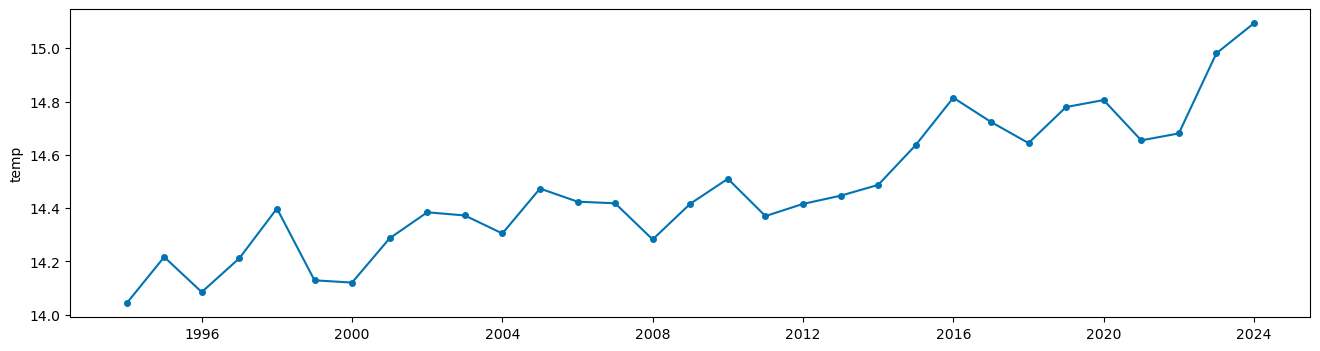

In [37]:
from sktime.utils.plotting import plot_series

plot_series(global_temp)

(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='temp'>)

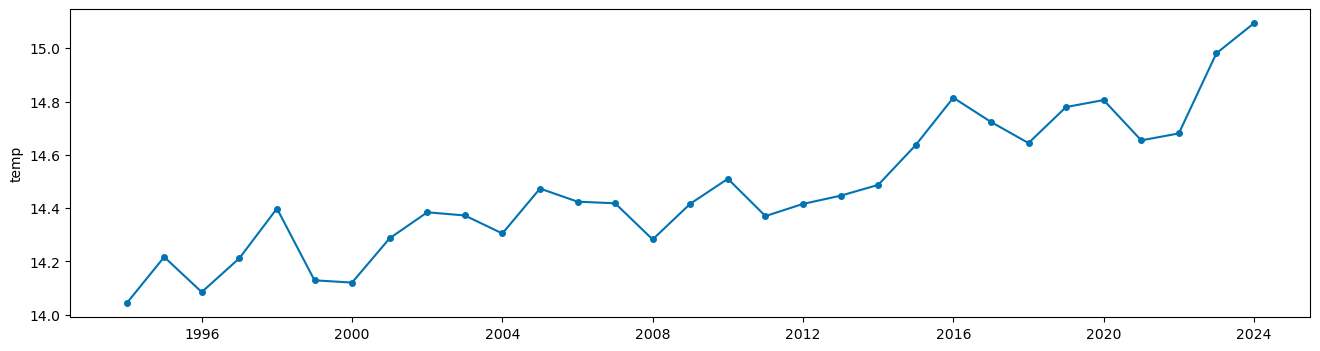

In [38]:
plot_series(global_temp.tail(36))

In [39]:
from sktime.forecasting.model_selection import temporal_train_test_split

y_train, y_test = temporal_train_test_split(global_temp, test_size = 6)
#print(y_train)

(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='temp'>)

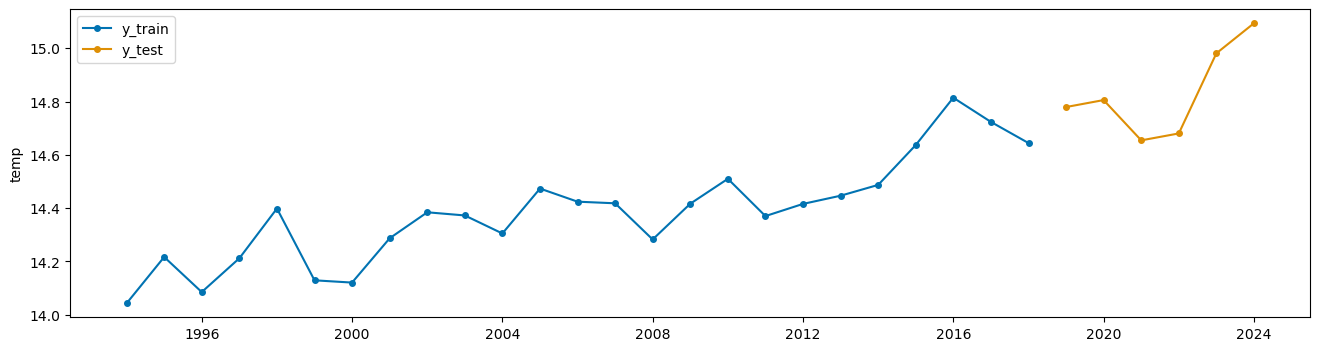

In [40]:
#print(type(y_test))

plot_series(y_train, y_test, labels=["y_train", "y_test"])

(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='temp'>)

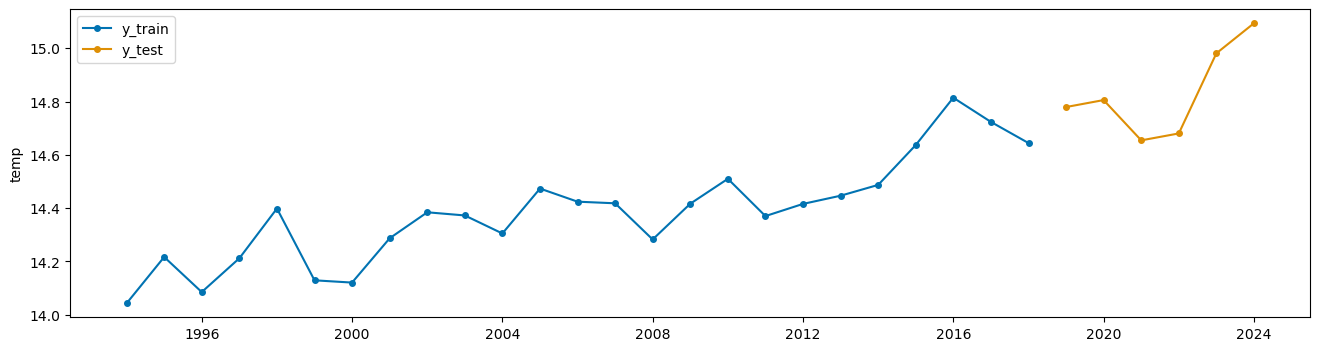

In [41]:
plot_series(y_train.tail(36), y_test, labels=["y_train", "y_test"])

In [42]:
from sktime.forecasting.arima import AutoARIMA

model = AutoARIMA(suppress_warnings=True)
model.fit(y_train)

AutoARIMA(suppress_warnings=True)

In [43]:
from sktime.forecasting.base import ForecastingHorizon

fh = ForecastingHorizon(y_test.index, is_relative=False)
fh

#fh = np.arange(len(y_test)) + 1
#fh

ForecastingHorizon(['2019', '2020', '2021', '2022', '2023', '2024'], dtype='period[Y-DEC]', is_relative=False)

(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='temp'>)

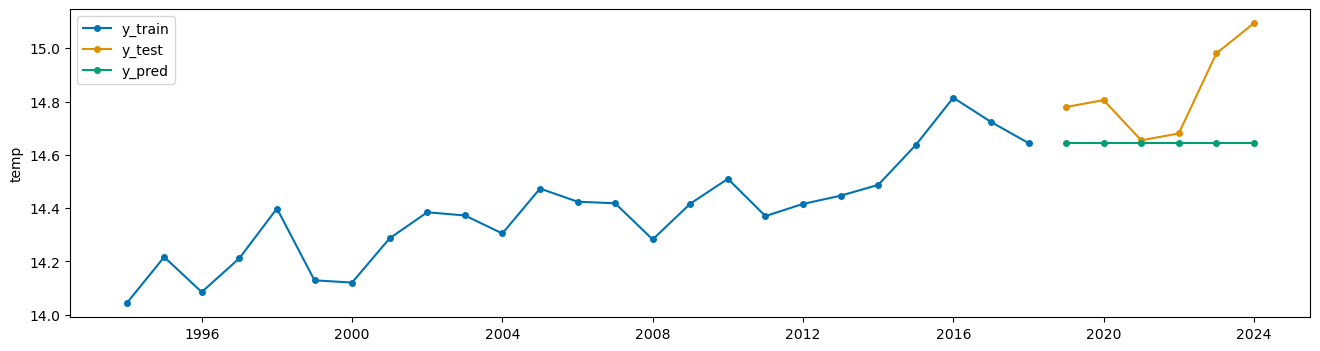

In [44]:
y_pred = model.predict(fh)

plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])

(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='temp'>)

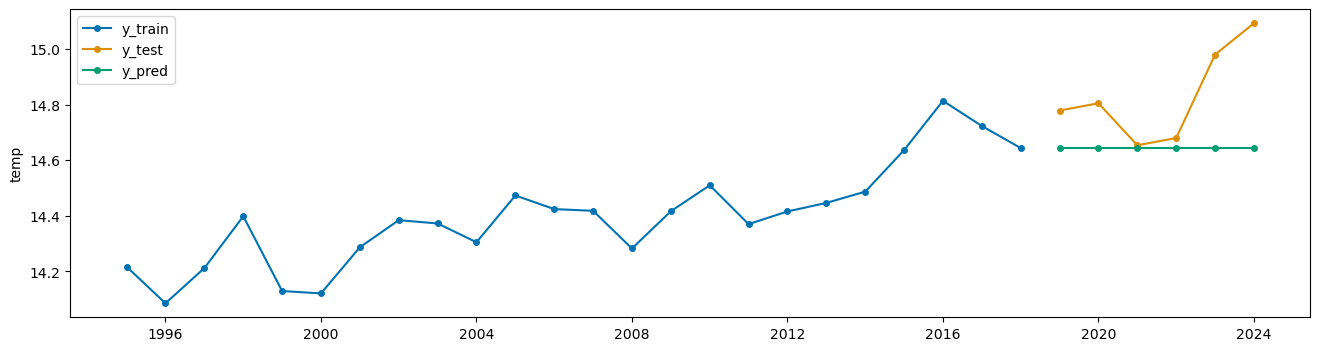

In [45]:
plot_series(y_train.tail(24), y_test, y_pred, labels=["y_train", "y_test", "y_pred"])

2019    14.644047
2020    14.644047
2021    14.644047
2022    14.644047
2023    14.644047
2024    14.644047
Freq: Y-DEC, Name: temp, dtype: float64


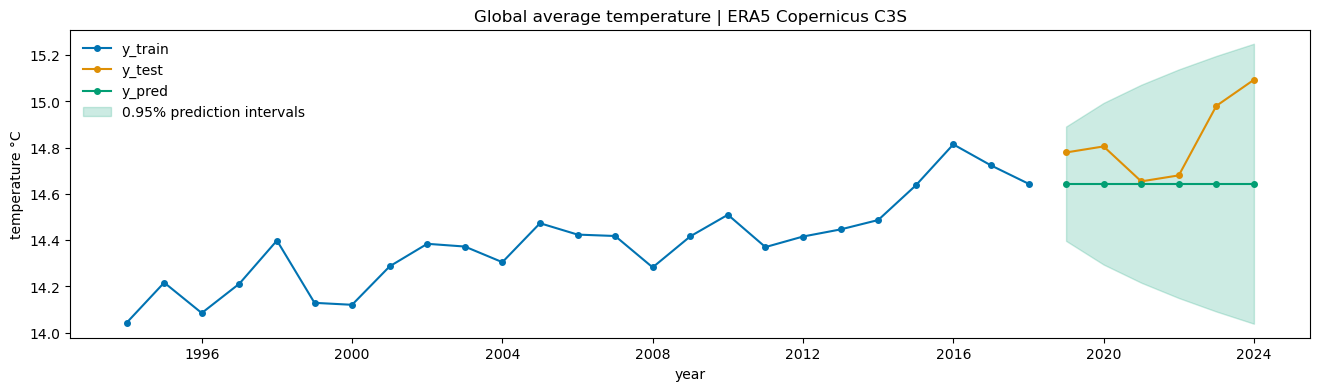

In [46]:
# 予測区間付き予測結果のグラフ
y_pred = model.predict(fh)
pred_ints = model.predict_interval(coverage=0.95)
fig, ax = plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])
ax.fill_between(
    ax.get_lines()[-1].get_xdata(),
    pred_ints.iloc[:,0],
    pred_ints.iloc[:,1],
    alpha=0.2,
    color=ax.get_lines()[-1].get_c(),
    label=f"{0.95}% prediction intervals",
)
ax.set_title(f'Global average temperature | {source}')
ax.set_xlabel('year')
ax.set_ylabel('temperature °C')
#ax.set_xticks(global_temp.index)
ax.tick_params(axis='x', colors='k', rotation=0)
ax.legend(labelcolor="k",facecolor='w', edgecolor='w',loc='upper left')
print(y_pred)

In [47]:
from sktime.performance_metrics.forecasting import mean_absolute_percentage_error #予測精度MAPE

mean_absolute_percentage_error(y_test, y_pred)

0.012576208616490876